# Bayesian Estimation of Temperature-Related Losses in PV Power Output

## 1. Problem formulation

### Problem statement

Photovoltaic power output depends mainly on solar irradiance, but it is also affected by module temperature. In standard PV performance models, higher cell temperature usually decreases DC power output due to the negative temperature coefficient of PV modules.

The main research question is:

**Does higher PV module temperature reduce normalized PV performance after accounting for irradiance?**

Instead of modelling raw DC power directly, the project models a normalized performance variable derived from the performance ratio concept:


$PR_i =
\frac{P_{DC,i} \cdot G_{STC}}
{P_{rated} \cdot G_{POA,i}},
\qquad
G_{STC}=1000~\mathrm{W/m^2}.$ [1]

where:

- $P_{DC,i}$ is measured DC power,
- $P_{rated}$ is rated DC power of the PV array,
- $G_{POA,i}$ is plane-of-array irradiance,
- $G_{STC}$ is reference irradiance under standard test conditions.

The response used for modelling is:


$y_i = \log(PR_i)$ .

This transformation is useful because $PR_i>0$, and regression coefficients can be interpreted approximately as relative/proportional changes.

### Objectives and use cases

The model is created to:

1. estimate the posterior distribution of the temperature effect on PV performance and quantify the uncertainty of this effect,
2. evaluate whether the probability of a negative temperature effect is high:


$P(\beta_T < 0 \mid \mathrm{data})$

3. compare a simple temperature-only model with a model that also includes wind speed,
4. optionally estimate the theoretical gain from cooling the PV module.

Potential practical use cases:

- estimating temperature-related PV power losses,
- assessing whether cooling-related effects are visible in real monitoring data,
- supporting simple PV performance modelling with uncertainty quantification,
- comparing empirical results with engineering PV models such as PVWatts.

### Data source

The project uses the **NIST Campus Photovoltaic (PV) Arrays and Weather Station Data Sets**.

Dataset source:

- NIST Photovoltaic Testbeds: https://www.nist.gov/el/beed/heat-transfer-alternative-energy-systems/photovoltaic-testbeds
- DOI: https://doi.org/10.18434/M3S67G

The original CSV files contain electrical, irradiance, temperature and weather measurements. The variables used in this project are:

| Variable | Meaning |
|---|---|
| `InvPDC_kW_Avg` | DC power measured at the inverter |
| `SEWSPOAIrrad_Wm2_Avg` | plane-of-array irradiance |
| `SEWSModuleTemp_C_Avg` | module temperature |
| `WindSpeedAve_ms` | average wind speed |
| `SEWSAmbientTemp_C_Avg` | ambient temperature |
| `TIMESTAMP` | measurement timestamp |

### DAG / causal intuition

A simplified causal structure is:

```text
solar irradiance  ───────────────→ PV power
       │                              ↑
       │                              │
       └────→ module temperature ─────┘

ambient temperature ─→ module temperature
wind speed ─────────→ module cooling ─→ module temperature
```

The main effect of interest is:

```text
module temperature → normalized PV performance
```

The wind speed variable is included in the second model because wind can cool the module and therefore may indirectly improve normalized performance.

## 2. Data selection and preprocessing

The raw NIST one-minute measurements were preprocessed to obtain a clean dataset suitable for Bayesian modelling of temperature-related PV performance losses. The analysis was restricted to the Ground Mount Array and to the summer period of 2016, using data from June, July and August.

The main goal of preprocessing was to keep measurements corresponding to stable, high-power operating conditions. This is important because the temperature effect is relatively small compared to the dominant effect of solar irradiance. Low-irradiance samples, rapidly changing irradiance conditions and obvious outliers could introduce effects related to clouds, low sun angle, shading or measurement noise rather than module temperature itself.

The final dataset contains the following variables:

$P_{DC}, \quad G_{POA}, \quad T_m, \quad v, \quad PR, \quad \log(PR)$,

where $P_{DC}$ is the measured DC power, $G_{POA} $ is the plane-of-array irradiance, $T_m$ is the module temperature, $v$ is the wind speed, and $PR$ is the normalized performance ratio.

The performance ratio was computed as:

$PR_i =
\frac{P_{DC,i} \cdot G_{STC}}
{P_{rated} \cdot G_{POA,i}},
\qquad
G_{STC}=1000~\mathrm{W/m^2}$.

This quantity removes the first-order influence of irradiance and allows the model to focus on remaining performance variations, especially those related to module temperature.

The following filtering criteria were applied:

$G_{POA} > 700~\mathrm{W/m^2}$,

$P_{DC} > 0$,

$11:00 \leq \mathrm{hour} \leq 14:00$,

$|\Delta G_{POA}| < 30~\mathrm{W/m^2/min}$,

$0.75 < PR < 1.15$.

The irradiance threshold keeps only high-power operating points. The time-of-day filter removes morning and evening samples, where the sun angle and geometric effects are stronger. The irradiance-change filter removes rapidly changing weather conditions, such as passing clouds. The performance-ratio filter removes physically suspicious measurements and extreme outliers.

For Bayesian modelling, the response variable is:


$y_i = \log(PR_i)$,

while the main predictors are scaled module temperature and standardized wind speed:

$x_{T,i} = \frac{T_{m,i} - 25}{10}$,


$z_{v,i} = \frac{v_i - \bar{v}}{s_v}$.


The transformed temperature variable (x_T) makes the temperature coefficient easier to interpret: one unit corresponds to a (10^\circ C) increase in module temperature.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path("ground_model_data.csv")

if not data_path.exists():
    raise FileNotFoundError(
        "Could not find ground_model_data.csv. "
    )

df = pd.read_csv(data_path)

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

df.head()

,timestamp,day,month,hour,logPR,PR,x_T,z_wind,T_module_C,wind_ms,G_POA_Wm2,P_DC_kW,expected_P_DC_kW,power_ratio
0,2016-06-01 11:01:00,2016-06-01 00:00:00,6,11.016667,-0.164772,0.848087,3.864,-0.916229,63.64,1.032,1009.0,231.9,273.439,0.848087
1,2016-06-01 11:03:00,2016-06-01 00:00:00,6,11.050000,-0.160566,0.851662,3.823,-0.518376,63.23,1.370,987.0,227.8,267.477,0.851662
2,2016-06-01 11:04:00,2016-06-01 00:00:00,6,11.066667,-0.154735,0.856642,3.711,-0.339459,62.11,1.522,986.0,228.9,267.206,0.856642
3,2016-06-01 11:07:00,2016-06-01 00:00:00,6,11.116667,-0.154614,0.856746,3.806,-1.209323,63.06,0.783,1010.0,234.5,273.710,0.856746
4,2016-06-01 11:08:00,2016-06-01 00:00:00,6,11.133333,-0.156146,0.855434,3.856,-1.139875,63.56,0.842,1015.0,235.3,275.065,0.855434


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3558 entries, 0 to 3557
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         3558 non-null   datetime64[us]
 1   day               3558 non-null   str           
 2   month             3558 non-null   int64         
 3   hour              3558 non-null   float64       
 4   logPR             3558 non-null   float64       
 5   PR                3558 non-null   float64       
 6   x_T               3558 non-null   float64       
 7   z_wind            3558 non-null   float64       
 8   T_module_C        3558 non-null   float64       
 9   wind_ms           3558 non-null   float64       
 10  G_POA_Wm2         3558 non-null   float64       
 11  P_DC_kW           3558 non-null   float64       
 12  expected_P_DC_kW  3558 non-null   float64       
 13  power_ratio       3558 non-null   float64       
dtypes: datetime64[us](1), float64(11), 

In [3]:
df.describe()

,timestamp,month,hour,logPR,PR,x_T,z_wind,T_module_C,wind_ms,G_POA_Wm2,P_DC_kW,expected_P_DC_kW,power_ratio
count,3558,3558.000000,3558.000000,3558.000000,3558.000000,3558.000000,3.558000e+03,3558.000000,3558.000000,3558.000000,3558.000000,3558.000000,3558.000000
mean,2016-08-01 13:39:20.978077,7.420180,12.455153,-0.115657,0.891201,2.989113,7.189303e-17,54.891127,1.810391,949.845756,229.165402,257.408200,0.891201
min,2016-06-01 11:01:00,6.000000,11.000000,-0.287484,0.750149,0.356000,-1.972071e+00,28.560000,0.135000,702.500000,152.900000,190.377500,0.750149
25%,2016-06-20 12:52:15,6.000000,11.700000,-0.134152,0.874457,2.670000,-7.043546e-01,51.700000,1.212000,906.000000,220.600000,245.526000,0.874457
50%,2016-08-15 11:57:30,8.000000,12.433333,-0.118366,0.888371,3.066000,-8.638680e-02,55.660000,1.737000,948.000000,228.200000,256.908000,0.888371
75%,2016-08-24 13:19:45,8.000000,13.216667,-0.095295,0.909105,3.408750,5.468831e-01,59.087500,2.275000,995.000000,237.400000,269.645000,0.909105
max,2016-08-31 13:46:00,8.000000,14.000000,0.041162,1.042021,4.168000,6.932550e+00,66.680000,7.700000,1232.000000,282.800000,333.872000,1.042021
std,NaN,0.887997,0.868469,0.030799,0.027239,0.572175,1.000000e+00,5.721753,0.849559,66.786167,14.276274,18.099051,0.027239


### Final variables used for modelling

The final modelling file contains:

| Column | Use |
|---|---|
| `logPR` | response variable |
| `PR` | normalized PV performance |
| `x_T` | scaled module temperature, \(x_T=(T_m-25)/10\) |
| `z_wind` | standardized wind speed |
| `T_module_C` | raw module temperature |
| `wind_ms` | raw wind speed |
| `G_POA_Wm2` | plane-of-array irradiance |
| `P_DC_kW` | measured DC power |

The Bayesian models use mainly:


$y_i = \log(PR_i),
\qquad$

$x_{T,i} = \frac{T_{m,i}-25}{10},
\qquad$
$z_{v,i} = \frac{v_i-\bar{v}}{s_v}$.


## 3. Exploratory data analysis

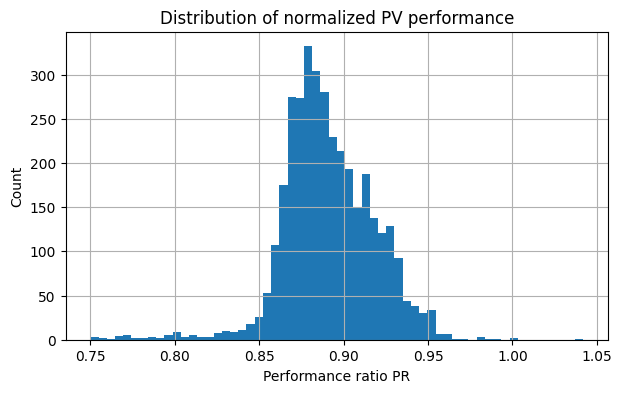

In [4]:
plt.figure(figsize=(7, 4))
plt.hist(df["PR"], bins=60)
plt.xlabel("Performance ratio PR")
plt.ylabel("Count")
plt.title("Distribution of normalized PV performance")
plt.grid(True)
plt.show()

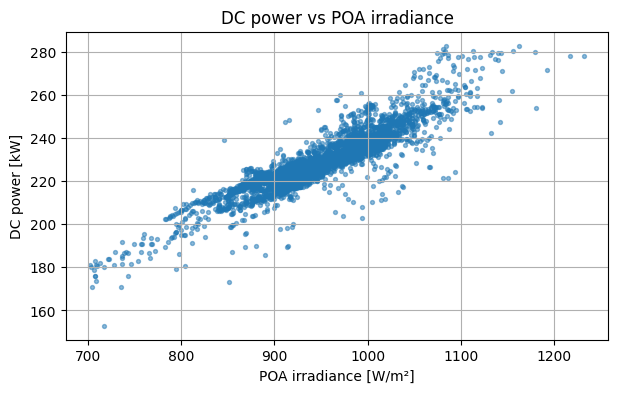

In [5]:
plt.figure(figsize=(7, 4))
plt.scatter(df["G_POA_Wm2"], df["P_DC_kW"], s=8, alpha=0.5)
plt.xlabel("POA irradiance [W/m²]")
plt.ylabel("DC power [kW]")
plt.title("DC power vs POA irradiance")
plt.grid(True)
plt.show()

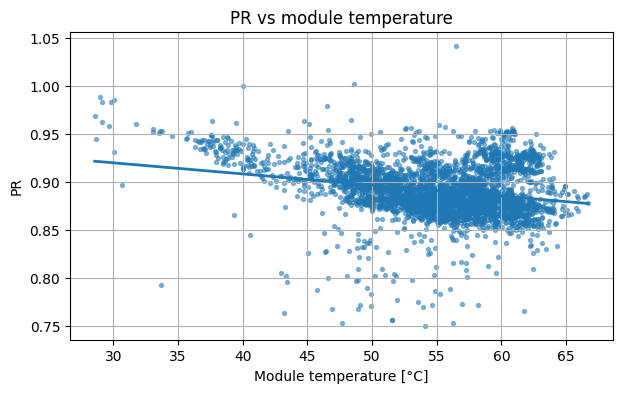

EDA linear slope: -0.00116 PR / °C


In [6]:
plt.figure(figsize=(7, 4))
plt.scatter(df["T_module_C"], df["PR"], s=8, alpha=0.5)

# Simple visual linear trend, only for EDA.
coef = np.polyfit(df["T_module_C"], df["PR"], 1)
x = np.linspace(df["T_module_C"].min(), df["T_module_C"].max(), 100)
plt.plot(x, coef[0] * x + coef[1], linewidth=2)

plt.xlabel("Module temperature [°C]")
plt.ylabel("PR")
plt.title("PR vs module temperature")
plt.grid(True)
plt.show()

print(f"EDA linear slope: {coef[0]:.5f} PR / °C")

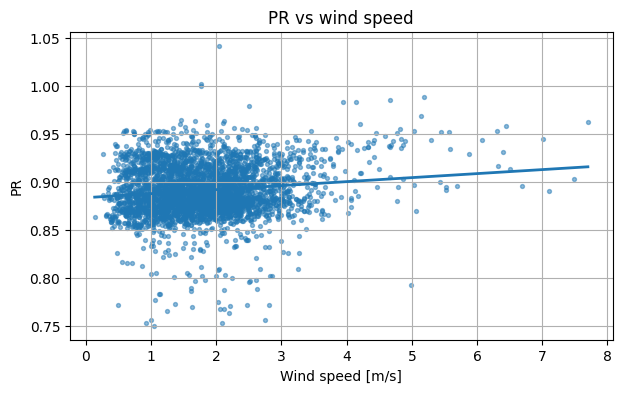

EDA linear slope: 0.00418 PR / (m/s)


In [7]:
plt.figure(figsize=(7, 4))
plt.scatter(df["wind_ms"], df["PR"], s=8, alpha=0.5)

coef = np.polyfit(df["wind_ms"], df["PR"], 1)
x = np.linspace(df["wind_ms"].min(), df["wind_ms"].max(), 100)
plt.plot(x, coef[0] * x + coef[1], linewidth=2)

plt.xlabel("Wind speed [m/s]")
plt.ylabel("PR")
plt.title("PR vs wind speed")
plt.grid(True)
plt.show()

print(f"EDA linear slope: {coef[0]:.5f} PR / (m/s)")

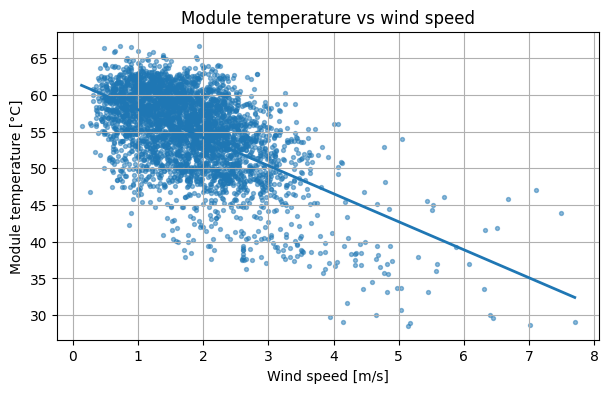

EDA linear slope: -3.81701 °C / (m/s)


In [8]:
plt.figure(figsize=(7, 4))
plt.scatter(df["wind_ms"], df["T_module_C"], s=8, alpha=0.5)

coef = np.polyfit(df["wind_ms"], df["T_module_C"], 1)
x = np.linspace(df["wind_ms"].min(), df["wind_ms"].max(), 100)
plt.plot(x, coef[0] * x + coef[1], linewidth=2)

plt.xlabel("Wind speed [m/s]")
plt.ylabel("Module temperature [°C]")
plt.title("Module temperature vs wind speed")
plt.grid(True)
plt.show()

print(f"EDA linear slope: {coef[0]:.5f} °C / (m/s)")

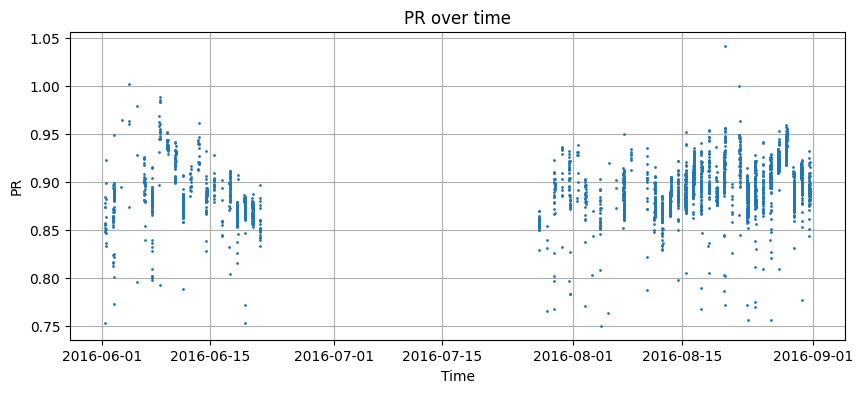

In [9]:
if "timestamp" in df.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(df["timestamp"], df["PR"], ".", markersize=2)
    plt.xlabel("Time")
    plt.ylabel("PR")
    plt.title("PR over time")
    plt.grid(True)
    plt.show()

C:\Users\Maria\AppData\Local\Temp\ipykernel_23364\3424788920.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_month, labels=months)


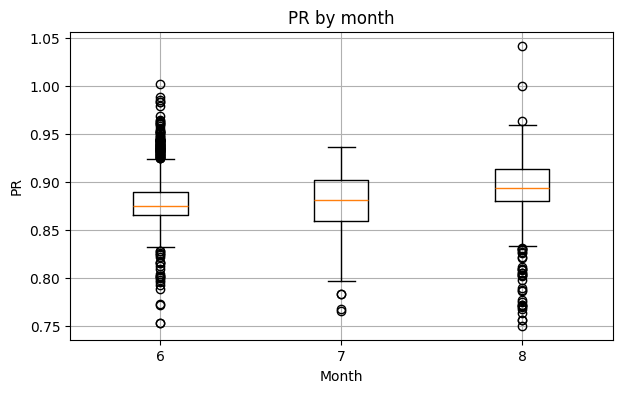

month
6     969
7     125
8    2464
dtype: int64


In [10]:
if "month" in df.columns:
    months = sorted(df["month"].unique())
    data_by_month = [df.loc[df["month"] == m, "PR"] for m in months]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data_by_month, labels=months)
    plt.xlabel("Month")
    plt.ylabel("PR")
    plt.title("PR by month")
    plt.grid(True)
    plt.show()

    print(df.groupby("month").size())

## 4. Proposed Bayesian models

Both models use a Student-T likelihood:

$y_i \sim \mathrm{StudentT}(\nu, \mu_i, \sigma)$,

where:

$y_i = \log(PR_i)$.

A Student-\(t\) likelihood is used because PV monitoring data can still contain outliers due to clouds, temporary shading, sensor noise or inverter behaviour, even after preprocessing.

### Model 1: temperature-only model

The first model estimates only the effect of module temperature:

$y_i \sim \mathrm{StudentT}(\nu, \mu_i, \sigma)$,

$\mu_i = \alpha + \beta_T x_{T,i}$.


where:

- $\alpha$ is the expected log-performance at minimal temperature,
- $\beta_T$ is the effect of a $10^\circ C$ increase in module temperature,
- $\sigma$ is residual variability,
- $\nu$ controls tail heaviness of the Student-T distribution.

The main quantity of interest is:

$P(\beta_T < 0 \mid \mathrm{data})$.

If this probability is high, the data support the hypothesis that higher module temperature reduces normalized PV performance.

### Model 2: temperature + wind model

The second model adds wind speed:

$y_i \sim \mathrm{StudentT}(\nu, \mu_i, \sigma)$,

$\mu_i = \alpha + \beta_T x_{T,i} + \beta_v z_{v,i}$.


where:

- $\beta_v$ is the effect of one standard deviation increase in wind speed.

The motivation is physical: wind can cool PV modules by convection. If this effect is visible in the data, the posterior for $\beta_v$ may concentrate above zero:

$P(\beta_v > 0 \mid \mathrm{data})$.

Model 2 is therefore justified as a physically motivated extension of Model 1.

## 5. Prior proposal

The predictors are scaled, so weakly informative priors can be used.

For both models:

$\alpha \sim \mathrm{Normal}(\log(0.75), 0.3)$,

Justification: the average value of \(PR\) is usually around 88-93% [2]. We decided to use a slightly weaker prior mean of 75% to allow for some bias in the data and to give the model more room to learn from the data. The standard deviation of 0.3 allows for a wide range of plausible average performance values.

$\beta_T \sim \mathrm{Normal}(0, 0.5)$,

because the prior should not force a negative temperature effect, but very large changes in log-performance per $10^\circ C $ are unlikely.

For Model 2:

$\beta_v \sim \mathrm{Normal}(0, 0.05)$.

For residual variation:

$\sigma \sim \mathrm{Exponential}(10)$.

For Student-T degrees of freedom:

$\nu = 2 + \mathrm{Exponential}(0.1)$.

The prior for $\beta_T$ can later be compared with a more physically informed sensitivity prior, for example:

$\beta_T \sim \mathrm{Normal}(-0.035, 0.03)$,

which corresponds roughly to a few percent loss per $10^\circ C$, consistent with typical PV temperature coefficient magnitudes.

## 6. Summary of modelling plan

The project will compare two Bayesian models:

| Model | Formula | Purpose |
|---|---|---|
| Model 1 | $\log(PR) \sim T_m$ | estimate basic temperature effect |
| Model 2 | $\log(PR) \sim T_m + wind$ | check whether wind improves the model |

The main expected result is a posterior estimate of the temperature effect, with uncertainty:

$p(\beta_T \mid \mathrm{data})$.

## References

[1] [PV Performance Modeling Collaborative. _Performance ratio_. Sandia National Laboratories.](https://pvpmc.sandia.gov/modeling-guide/5-ac-system-output/pv-performance-metrics/performance-ratio/)

[2] [Herteleer, Bert & Huyck, Bart & Catthoor, Francky & Driesen, Johan & Cappelle, Jan. (2017). Normalised efficiency of photovoltaic systems: Going beyond the performance ratio. Solar Energy. 157. 408-418. 10.1016/j.solener.2017.08.037.](https://www.researchgate.net/publication/319422942_Normalised_efficiency_of_photovoltaic_systems_Going_beyond_the_performance_ratio)

do wartości beta_t_10c (-3.5% na 10 stopni C): https://docs.nlr.gov/docs/fy13osti/57991.pdf https://pvpmc.sandia.gov/modeling-guide/5-ac-system-output/pv-performance-metrics/normalized-efficiency/ (oba uwzgleniaja nasz wzor PR)